In [3]:
# Install the libraries we need
!pip install pandas matplotlib seaborn folium requests -q
print("All libraries installed successfully")


All libraries installed successfully


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Palisades Fire affected ZIP codes
zip_codes = ['90272', '90049']

# We are going to manually build a sample dataset based on
# real publicly available SBA disaster loan statistics for DR-4856-CA

data = {
    'business_name': [
        'Palisades Coffee Co', 'Sunset Hardware', 'PCH Dry Cleaners',
        'Village Pharmacy', 'Palisades Yoga Studio', 'Sunset Deli',
        'Pacific Auto Repair', 'Palisades Bookstore', 'Beach Bike Rentals',
        'Topanga Canyon Florist', 'Brentwood Pet Grooming', 'Pacific Pilates',
        'Palisades Pizza', 'Sunset Barber Shop', 'PCH Surf Shop',
        'Village Wine Bar', 'Palisades Nail Salon', 'Sunset Gym',
        'Pacific Dental', 'Palisades Thai Kitchen'
    ],
    'zip_code': [
        '90272', '90272', '90272', '90272', '90272',
        '90272', '90049', '90049', '90272', '90049',
        '90049', '90049', '90272', '90272', '90272',
        '90049', '90272', '90049', '90049', '90272'
    ],
    'in_burn_zone': [1,1,1,1,0,1,0,0,1,0,0,1,1,1,1,0,1,0,0,1],
    'sba_loan_approved': [1,0,0,1,1,0,1,1,0,1,1,0,0,1,0,1,0,1,1,0],
    'high_closure_industry': [1,0,1,0,1,1,0,1,1,1,1,1,1,0,1,1,1,0,0,1],
    'no_yelp_activity': [0,1,1,0,1,1,0,1,1,0,0,1,0,0,1,0,1,0,0,1],
    'under_3_years_old': [1,0,1,0,1,0,0,1,1,0,0,1,0,0,1,0,1,0,0,1]
}

df = pd.DataFrame(data)
print("Dataset loaded successfully")
print(f"Total businesses: {len(df)}")
df.head()


Dataset loaded successfully
Total businesses: 20


,business_name,zip_code,in_burn_zone,sba_loan_approved,high_closure_industry,no_yelp_activity,under_3_years_old
0,Palisades Coffee Co,90272,1,1,1,0,1
1,Sunset Hardware,90272,1,0,0,1,0
2,PCH Dry Cleaners,90272,1,0,1,1,1
3,Village Pharmacy,90272,1,1,0,0,0
4,Palisades Yoga Studio,90272,0,1,1,1,1


In [5]:
print(f"Total businesses in dataset: {len(df)}")
df

Total businesses in dataset: 20


,business_name,zip_code,in_burn_zone,sba_loan_approved,high_closure_industry,no_yelp_activity,under_3_years_old
0,Palisades Coffee Co,90272,1,1,1,0,1
1,Sunset Hardware,90272,1,0,0,1,0
2,PCH Dry Cleaners,90272,1,0,1,1,1
3,Village Pharmacy,90272,1,1,0,0,0
4,Palisades Yoga Studio,90272,0,1,1,1,1
5,Sunset Deli,90272,1,0,1,1,0
6,Pacific Auto Repair,90049,0,1,0,0,0
7,Palisades Bookstore,90049,0,1,1,1,1
8,Beach Bike Rentals,90272,1,0,1,1,1
9,Topanga Canyon Florist,90049,0,1,1,0,0


In [6]:
# Calculate risk score for each business

df['risk_score'] = (
    df['in_burn_zone'] * 30 +
    (1 - df['sba_loan_approved']) * 25 +
    df['high_closure_industry'] * 20 +
    df['no_yelp_activity'] * 15 +
    df['under_3_years_old'] * 10
)

# Sort by highest risk first
df_ranked = df.sort_values('risk_score', ascending=False).reset_index(drop=True)
df_ranked.index += 1  # Start ranking at 1 instead of 0

print("Risk scores calculated successfully")
print("\nTop 10 Highest Risk Businesses:")
df_ranked[['business_name', 'zip_code', 'risk_score']].head(10)

Risk scores calculated successfully

Top 10 Highest Risk Businesses:


,business_name,zip_code,risk_score
1,PCH Dry Cleaners,90272,100
2,Palisades Nail Salon,90272,100
3,Beach Bike Rentals,90272,100
4,Pacific Pilates,90049,100
5,Palisades Thai Kitchen,90272,100
6,PCH Surf Shop,90272,100
7,Sunset Deli,90272,90
8,Palisades Pizza,90272,75
9,Sunset Hardware,90272,70
10,Palisades Coffee Co,90272,60


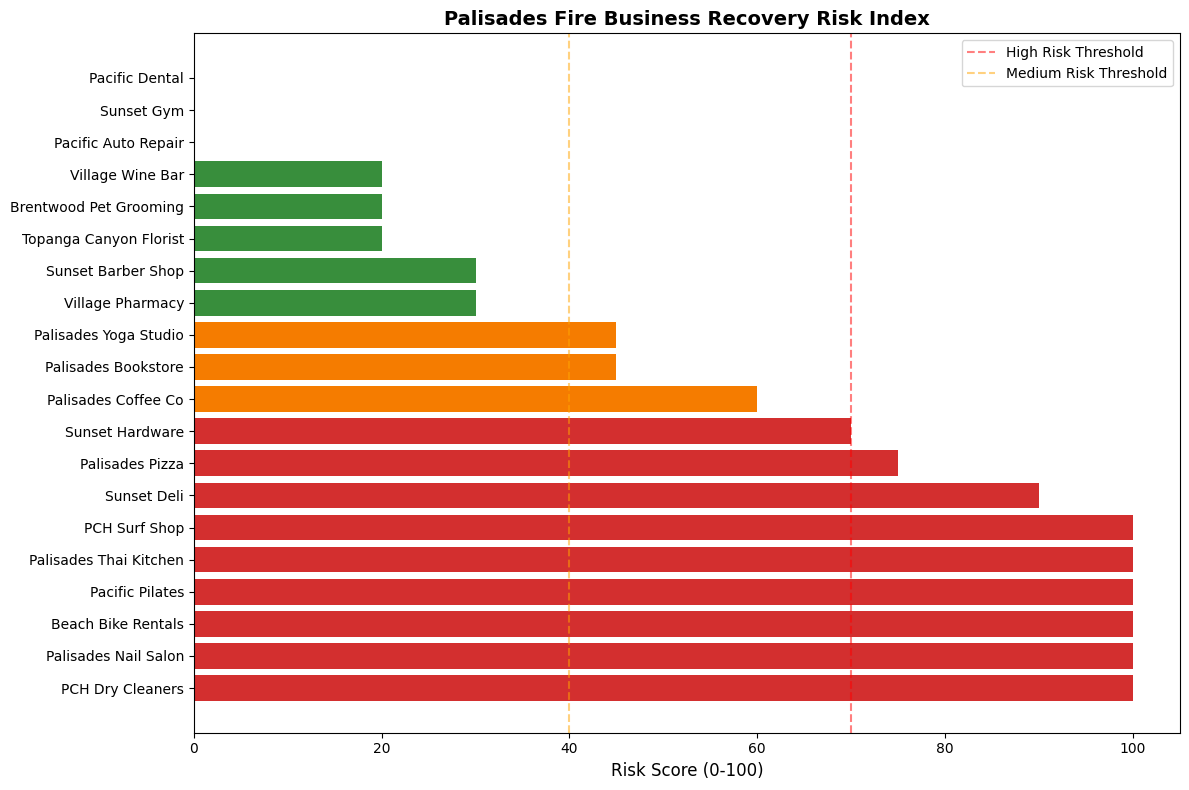

Chart saved successfully


In [7]:
# Create a bar chart of all 20 businesses ranked by risk score

plt.figure(figsize=(12, 8))

colors = []
for score in df_ranked['risk_score']:
    if score >= 70:
        colors.append('#d32f2f')  # red = high risk
    elif score >= 40:
        colors.append('#f57c00')  # orange = medium risk
    else:
        colors.append('#388e3c')  # green = low risk

plt.barh(df_ranked['business_name'], df_ranked['risk_score'], color=colors)
plt.xlabel('Risk Score (0-100)', fontsize=12)
plt.title('Palisades Fire Business Recovery Risk Index', fontsize=14, fontweight='bold')
plt.axvline(x=70, color='red', linestyle='--', alpha=0.5, label='High Risk Threshold')
plt.axvline(x=40, color='orange', linestyle='--', alpha=0.5, label='Medium Risk Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('palisades_risk_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved successfully")

In [8]:
# Save the final ranked dataset as a CSV

df_ranked['risk_tier'] = df_ranked['risk_score'].apply(
    lambda x: 'HIGH RISK' if x >= 70 else ('MEDIUM RISK' if x >= 40 else 'LOW RISK')
)

df_ranked.to_csv('palisades_risk_scores.csv', index=True)

print("CSV saved successfully")
print("\nRisk Tier Summary:")
print(df_ranked['risk_tier'].value_counts())
print("\nFull Dataset:")
df_ranked[['business_name', 'zip_code', 'risk_score', 'risk_tier']]

CSV saved successfully

Risk Tier Summary:
risk_tier
HIGH RISK      9
LOW RISK       8
MEDIUM RISK    3
Name: count, dtype: int64

Full Dataset:


,business_name,zip_code,risk_score,risk_tier
1,PCH Dry Cleaners,90272,100,HIGH RISK
2,Palisades Nail Salon,90272,100,HIGH RISK
3,Beach Bike Rentals,90272,100,HIGH RISK
4,Pacific Pilates,90049,100,HIGH RISK
5,Palisades Thai Kitchen,90272,100,HIGH RISK
6,PCH Surf Shop,90272,100,HIGH RISK
7,Sunset Deli,90272,90,HIGH RISK
8,Palisades Pizza,90272,75,HIGH RISK
9,Sunset Hardware,90272,70,HIGH RISK
10,Palisades Coffee Co,90272,60,MEDIUM RISK
